# Root-Cause Analysis Triage Report

The explanation analysis converts the trained baseline model into a ranked set of sensor investigation candidates. The results are empirical attribution and distribution signals from the current model and processed test split; they identify where the model finds failure-related structure, not confirmed physical root causes.

The strongest composite candidates are `sensor_164`, `sensor_059`, `sensor_025`, `sensor_151`, and `sensor_045`. These sensors combine high SHAP attribution, fail/pass attribution differences, and SPC flag behavior more strongly than the rest of the feature set.

## Data and Model Context

The analysis uses the trained baseline model from notebook 04 and the same processed train/test data. The test set contains 314 wafers and 198 sensor features. Because notebook 04 showed limited predictive strength, the ranked sensors below are best interpreted as prioritization evidence for engineering review rather than final causal assignments.

In [1]:
from __future__ import annotations

import contextlib
import io
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from yield_risk.config import load_config
from yield_risk.explainability import compute_shap_values, global_feature_importance, save_shap_values
from yield_risk.root_cause import fail_shap_lift, rank_root_cause_candidates, spc_flag_rate

In [2]:
cfg = load_config(ROOT / "configs" / "config.yaml")

model_path = ROOT / "models" / "baseline_lr.joblib"
train_path = ROOT / "data" / "processed" / "train.csv"
test_path = ROOT / "data" / "processed" / "test.csv"

required_paths = [model_path, train_path, test_path]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Model and processed data artifacts are required. Missing: "
        + ", ".join(str(path) for path in missing_paths)
    )

pipeline = joblib.load(model_path)
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

sensor_cols = [column for column in test.columns if column.startswith("sensor_")]
if not sensor_cols:
    raise ValueError("No sensor_* columns found in processed test data.")

X_train = train[sensor_cols]
X_test = test[sensor_cols]
y_test = test["label"].to_numpy()

print(f"Loaded model: {model_path}")
print(f"Train rows: {len(train):,}; test rows: {len(test):,}; sensors: {len(sensor_cols):,}")

Loaded model: C:\Users\Virgil\Code\semiconductor-yield-root-cause\models\baseline_lr.joblib
Train rows: 1,253; test rows: 314; sensors: 198


## Explanation Signals

Three signals are combined for each sensor: mean absolute SHAP value, fail/pass SHAP lift, and SPC flag rate. Mean absolute SHAP measures how strongly the model uses a sensor overall. SHAP lift measures whether attribution differs between failing and passing wafers. SPC flag rate measures how often the sensor falls outside a simple mean plus or minus three-sigma band.

The composite score emphasizes sensors that are important to the model, differ by outcome class, and show some statistical process-control abnormality in the held-out data.

In [3]:
shap_stdout = io.StringIO()
with contextlib.redirect_stdout(shap_stdout), contextlib.redirect_stderr(shap_stdout):
    explanations = compute_shap_values(pipeline, X_train, X_test)
global_importance = global_feature_importance(explanations)
flag_rates = spc_flag_rate(test, sensor_cols)
shap_lift = fail_shap_lift(explanations, y_test)
candidates = rank_root_cause_candidates(global_importance, shap_lift, flag_rates)

print(
    f"Computed SHAP explanations for {len(X_test):,} test rows "
    f"and {len(sensor_cols):,} sensor features."
)
print(
    "Composite ranking combines mean absolute SHAP, fail/pass SHAP lift, "
    "and SPC flag rate."
)
candidates.head(15)

Computed SHAP explanations for 314 test rows and 198 sensor features.
Composite ranking combines mean absolute SHAP, fail/pass SHAP lift, and SPC flag rate.


,sensor,mean_abs_shap,shap_lift,spc_flag_rate,composite_score
0,sensor_164,0.758039,-2.086456,0.022293,0.730750
1,sensor_059,0.863337,1.500850,0.019108,0.683343
2,sensor_025,1.086781,-0.670783,0.022293,0.678801
3,sensor_151,1.047141,0.450714,0.009554,0.581819
4,sensor_045,1.016673,-0.110621,0.006369,0.507104
5,sensor_014,0.908209,0.120211,0.003185,0.446699
6,sensor_061,0.689336,-0.216668,0.015924,0.406691
7,sensor_573,0.582412,0.159914,0.028662,0.396280
8,sensor_064,0.675771,-0.120351,0.015924,0.386586
9,sensor_026,0.458758,0.619080,0.022293,0.381747


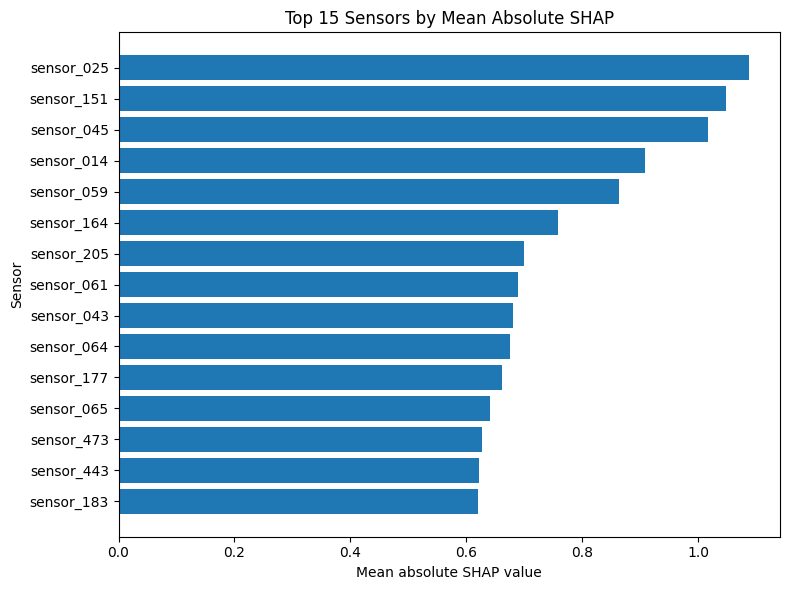

In [4]:
top_n = 15
top_importance = global_importance.head(top_n).sort_values("mean_abs_shap")

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_importance["feature"], top_importance["mean_abs_shap"])
ax.set_title(f"Top {top_n} Sensors by Mean Absolute SHAP")
ax.set_xlabel("Mean absolute SHAP value")
ax.set_ylabel("Sensor")
plt.tight_layout()

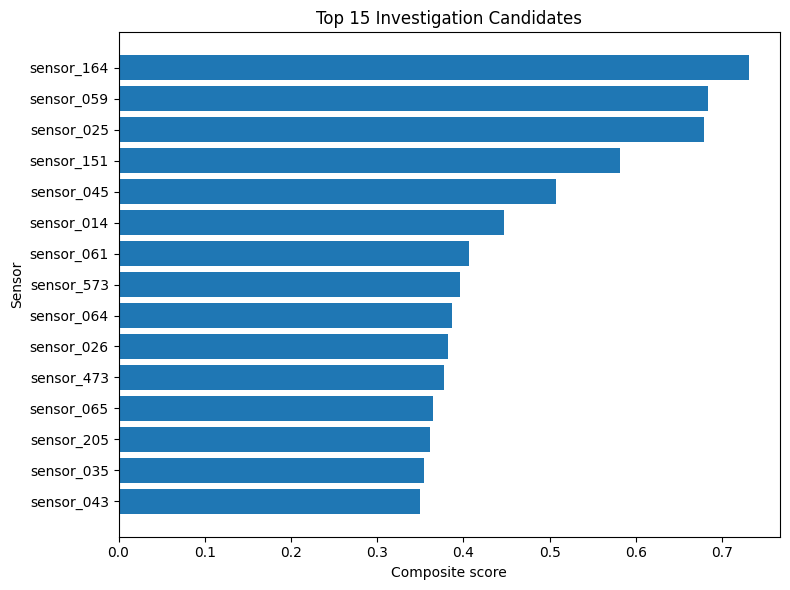

In [5]:
top_candidates = candidates.head(top_n).sort_values("composite_score")

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_candidates["sensor"], top_candidates["composite_score"])
ax.set_title(f"Top {top_n} Investigation Candidates")
ax.set_xlabel("Composite score")
ax.set_ylabel("Sensor")
plt.tight_layout()

## Candidate Distribution Review

The top-ranked candidates have mixed evidence. `sensor_164` has the highest composite score with strong negative SHAP lift and a 2.23% SPC flag rate. `sensor_059` has the strongest positive SHAP lift among the top five, while `sensor_025` has the largest mean absolute SHAP value. The distribution plots compare pass and fail density directly, exposing whether these rankings reflect broad separation or a small number of tail observations.

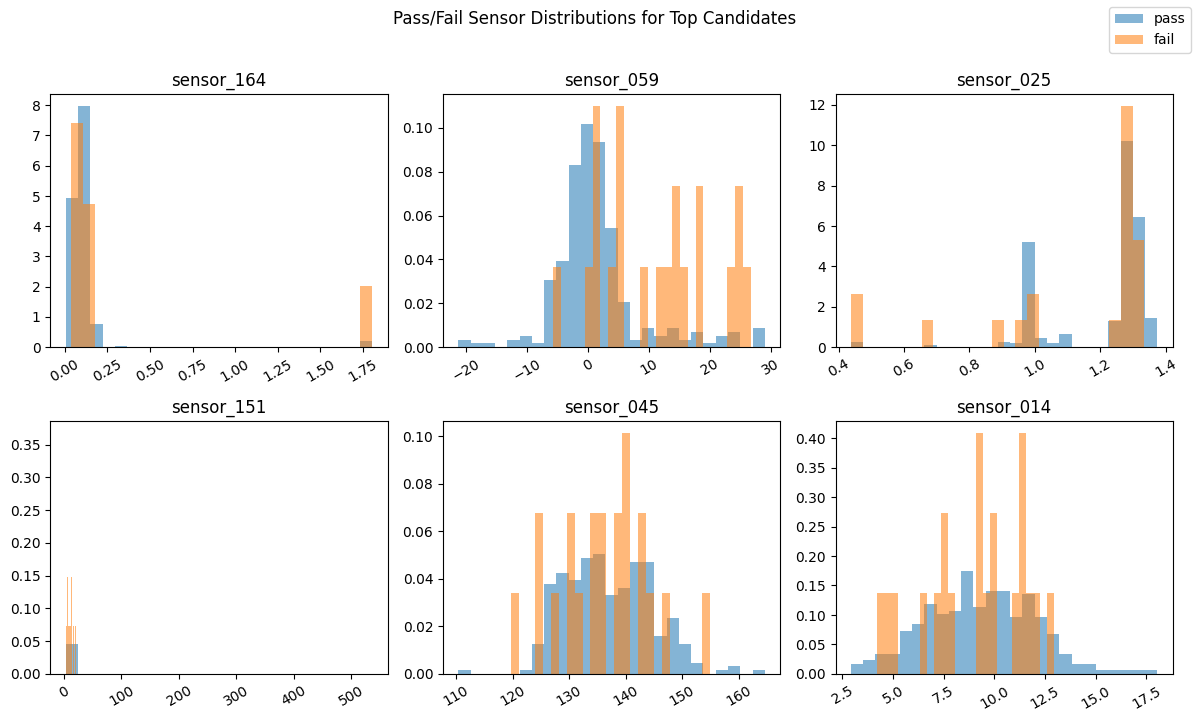

In [6]:
sensors_to_plot = candidates.head(6)["sensor"].tolist()

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, sensor in zip(axes.ravel(), sensors_to_plot, strict=False):
    passing = test.loc[test["label"] == 0, sensor].dropna()
    failing = test.loc[test["label"] == 1, sensor].dropna()
    ax.hist(passing, bins=25, alpha=0.55, label="pass", density=True)
    ax.hist(failing, bins=25, alpha=0.55, label="fail", density=True)
    ax.set_title(sensor)
    ax.tick_params(axis="x", labelrotation=30)

for ax in axes.ravel()[len(sensors_to_plot):]:
    ax.axis("off")

handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Pass/Fail Sensor Distributions for Top Candidates", y=1.02)
plt.tight_layout()

## Persisted Review Artifacts

The SHAP values, global SHAP importance, and ranked root-cause candidate table are stored in `reports/`. These artifacts preserve the exact attribution results used in this report and provide the tabular inputs for follow-up process analysis.

In [7]:
reports_dir = ROOT / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

save_shap_values(explanations, reports_dir / "shap_values.npz")
global_importance.to_csv(reports_dir / "shap_global_importance.csv", index=False)
candidates.to_csv(reports_dir / "root_cause_candidates.csv", index=False)

print(f"Saved review artifacts to {reports_dir}")

Saved review artifacts to C:\Users\Virgil\Code\semiconductor-yield-root-cause\reports


## Empirical Interpretation

The root-cause triage output is consistent with the modeling limits observed in notebook 04. The same sensor family that appears in the linear coefficient ranking also appears in SHAP-based triage: `sensor_164`, `sensor_059`, `sensor_025`, `sensor_151`, and `sensor_205` all rank highly in at least one model-importance view. That agreement strengthens their value as investigation candidates.

The evidence remains correlational. The baseline model has low recall at the default threshold and only moderate ROC-AUC, so these rankings are a short list for engineering validation. A physically credible root-cause conclusion would require persistence across time, lots, tools, or process context beyond the sensor-only model outputs shown here.